# Практическая работа №1. Анализ FiresRu

**Цель:** изучить структуру данных, выполнить предобработку, статистический анализ, визуализацию и экспорт.

**Источник:** файл `FiresRu.csv` из задания. Каждая строка содержит тип события, координаты и метеорологические показатели. Даты наблюдений и единицы влажности и солнечной радиации не указаны.

## 2.1. Проверка окружения

In [1]:
from pathlib import Path
import csv
import io
import json
import platform
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib
import pyarrow
from IPython.display import display, Markdown

matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

ROOT = Path.cwd()
assert (ROOT / "FiresRu.csv").exists(), "Откройте ноутбук из папки практики BD."
OUT = ROOT / "output" / "fires"
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 3)
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11, "figure.dpi": 110})
versions = {"Python": platform.python_version(), "pandas": pd.__version__,
            "numpy": np.__version__, "matplotlib": matplotlib.__version__,
            "pyarrow": pyarrow.__version__}
display(pd.Series(versions, name="Версия").to_frame())
display(Markdown("**Вывод.** Библиотеки для анализа данных загружены."))

,Версия
Python,3.11.9
pandas,2.3.3
numpy,2.4.6
matplotlib,3.11.1
pyarrow,25.0.1


**Вывод.** Библиотеки для анализа данных загружены.

## 3.1-3.2. NumPy, Series и DataFrame

In [2]:
wind_ms = np.array([1.14, 0.80, 0.97])
print("Ветер, км/ч:", np.round(wind_ms * 3.6, 2))
s = pd.Series([10, 20, 30], name="value")
frame = pd.DataFrame({"type": ["A", "B", "A"], "value": [10, 20, 30]})
print(type(s).__name__, type(frame).__name__)
display(frame.groupby("type")["value"].sum().to_frame())
display(Markdown("**Вывод.** Векторное умножение переводит весь массив из м/с в км/ч. "
                 "Series представляет один столбец, DataFrame - таблицу. Суммы групп A и B равны 40 и 20."))

Ветер, км/ч: [4.1  2.88 3.49]
Series DataFrame


,value
type,
A,40
B,20


**Вывод.** Векторное умножение переводит весь массив из м/с в км/ч. Series представляет один столбец, DataFrame - таблицу. Суммы групп A и B равны 40 и 20.

## 4.1. Загрузка и паспорт данных

In [3]:
DATA_PATH = ROOT / "FiresRu.csv"
raw_text = DATA_PATH.read_text(encoding="utf-8-sig")
delimiter = csv.Sniffer().sniff(raw_text[:8192], delimiters=",;\t").delimiter
assert delimiter == ","
df = pd.read_csv(DATA_PATH, sep=delimiter, encoding="utf-8-sig")
print("Разделитель:", repr(delimiter), "; UTF-8 декодируется без ошибок")
print("Размер:", df.shape)
print("Столбцы:", df.columns.tolist())
assert df.shape == (26681, 9)
display(df.head())
meanings = {
    "type_name": "Название категории события", "type_id": "Код категории, не количественная величина",
    "lon": "Долгота, градусы", "lat": "Широта, градусы",
    "temperature_c": "Температура, °C", "precipitation_mm": "Осадки, мм",
    "relative_humidity": "Относительная влажность, единица не задана",
    "wind_speed_ms": "Скорость ветра, м/с", "solar_radiation": "Солнечная радиация, единица не задана",
}
display(pd.DataFrame({"Смысл": meanings, "dtype": df.dtypes.astype(str)}))
display(Markdown(f"**Вывод.** Прочитано {len(df):,} строк и {df.shape[1]} полей. "
                 "Разделитель и состав полей соответствуют методичке. Временного признака нет."))

Разделитель: ',' ; UTF-8 декодируется без ошибок
Размер: (26681, 9)
Столбцы: ['type_name', 'type_id', 'lon', 'lat', 'temperature_c', 'precipitation_mm', 'relative_humidity', 'wind_speed_ms', 'solar_radiation']


,type_name,type_id,lon,lat,temperature_c,precipitation_mm,relative_humidity,wind_speed_ms,solar_radiation
0,Natural fire,4,131.587,47.866,-9.44,0.01,72.98,1.14,4.59
1,Natural fire,4,131.589,47.881,-9.44,0.01,72.98,1.14,4.59
2,Forest fire,3,131.987,48.497,-10.71,0.05,81.31,0.80,4.24
3,Natural fire,4,131.903,43.628,-7.77,0.00,68.41,0.97,4.66
4,Natural fire,4,131.571,47.858,-9.44,0.01,72.98,1.14,4.59


,Смысл,dtype
type_name,Название категории события,object
type_id,"Код категории, не количественная величина",int64
lon,"Долгота, градусы",float64
lat,"Широта, градусы",float64
temperature_c,"Температура, °C",float64
precipitation_mm,"Осадки, мм",float64
relative_humidity,"Относительная влажность, единица не задана",float64
wind_speed_ms,"Скорость ветра, м/с",float64
solar_radiation,"Солнечная радиация, единица не задана",float64


**Вывод.** Прочитано 26,681 строк и 9 полей. Разделитель и состав полей соответствуют методичке. Временного признака нет.

## 5.1-5.2. Структура, память и качество

In [4]:
buf = io.StringIO()
df.info(buf=buf, memory_usage="deep")
print(buf.getvalue())
quality = pd.DataFrame({"Пропуски": df.isna().sum(), "Уникальных": df.nunique(),
                        "dtype": df.dtypes.astype(str)})
display(quality)
duplicates = int(df.duplicated().sum())
print("Полных дубликатов:", duplicates)
validity = pd.Series({
    "Долгота вне [-180; 180]": int((~df.lon.between(-180, 180)).sum()),
    "Широта вне [-90; 90]": int((~df.lat.between(-90, 90)).sum()),
    "Отрицательные осадки": int((df.precipitation_mm < 0).sum()),
    "Отрицательная скорость ветра": int((df.wind_speed_ms < 0).sum()),
    "Бесконечные числовые значения": int(np.isinf(df.select_dtypes("number")).sum().sum()),
}, name="Строк/значений")
display(validity.to_frame())
assert df.isna().sum().sum() == 0 and duplicates == 0 and validity.sum() == 0
display(Markdown("**Вывод.** Пропусков, полных дублей и нарушений проверенных диапазонов нет. "
                 "Удаление строк и заполнение пропусков не требуются."))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26681 entries, 0 to 26680
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   type_name          26681 non-null  object 
 1   type_id            26681 non-null  int64  
 2   lon                26681 non-null  float64
 3   lat                26681 non-null  float64
 4   temperature_c      26681 non-null  float64
 5   precipitation_mm   26681 non-null  float64
 6   relative_humidity  26681 non-null  float64
 7   wind_speed_ms      26681 non-null  float64
 8   solar_radiation    26681 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 3.4 MB



,Пропуски,Уникальных,dtype
type_name,0,5,object
type_id,0,5,int64
lon,0,25708,float64
lat,0,23547,float64
temperature_c,0,2581,float64
precipitation_mm,0,571,float64
relative_humidity,0,4028,float64
wind_speed_ms,0,532,float64
solar_radiation,0,731,float64


Полных дубликатов: 0


,Строк/значений
Долгота вне [-180; 180],0
Широта вне [-90; 90],0
Отрицательные осадки,0
Отрицательная скорость ветра,0
Бесконечные числовые значения,0


**Вывод.** Пропусков, полных дублей и нарушений проверенных диапазонов нет. Удаление строк и заполнение пропусков не требуются.

## 5.3. Соответствие кода и названия категории

In [5]:
type_map = df[["type_id", "type_name"]].drop_duplicates().sort_values("type_id")
display(type_map.reset_index(drop=True))
assert type_map.type_id.is_unique and type_map.type_name.is_unique
display(Markdown("**Вывод.** Пять кодов взаимно однозначно соответствуют пяти названиям. "
                 "Среднее `type_id` не имеет содержательной интерпретации, поэтому код исключён из EDA числовых величин."))

,type_id,type_name
0,1,Uncontrolled burn
1,2,Peat fire
2,3,Forest fire
3,4,Natural fire
4,5,Controlled burn


**Вывод.** Пять кодов взаимно однозначно соответствуют пяти названиям. Среднее `type_id` не имеет содержательной интерпретации, поэтому код исключён из EDA числовых величин.

## 5.4. Описательная статистика

In [6]:
cols = ["lon", "lat", "temperature_c", "precipitation_mm", "relative_humidity",
        "wind_speed_ms", "solar_radiation"]
description = df[cols].describe().T
display(description.round(2))
display(Markdown(
    f"**Вывод.** Температура: от {df.temperature_c.min():.2f} до {df.temperature_c.max():.2f} °C, "
    f"медиана {df.temperature_c.median():.2f} °C. Медиана осадков {df.precipitation_mm.median():.2f} мм "
    f"при максимуме {df.precipitation_mm.max():.2f} мм; медиана ветра {df.wind_speed_ms.median():.2f} м/с "
    f"при максимуме {df.wind_speed_ms.max():.2f} м/с. Большие верхние значения указывают на правые хвосты распределений."
))

,count,mean,std,min,25%,50%,75%,max
lon,26681.0,106.35,27.31,20.37,82.41,96.56,133.90,175.87
lat,26681.0,57.53,4.30,41.71,53.95,58.97,60.64,70.33
temperature_c,26681.0,17.89,5.68,-34.88,15.70,19.08,21.39,31.94
precipitation_mm,26681.0,0.46,1.46,0.00,0.00,0.04,0.30,25.85
relative_humidity,26681.0,69.44,11.43,24.70,62.93,71.35,77.91,99.83
wind_speed_ms,26681.0,0.63,0.93,0.00,0.11,0.25,0.66,7.42
solar_radiation,26681.0,5.57,1.50,0.42,4.55,5.68,6.71,8.97


**Вывод.** Температура: от -34.88 до 31.94 °C, медиана 19.08 °C. Медиана осадков 0.04 мм при максимуме 25.85 мм; медиана ветра 0.25 м/с при максимуме 7.42 м/с. Большие верхние значения указывают на правые хвосты распределений.

## 6.1. Оптимизация типов
Память сравнивается до добавления вычисляемых признаков, на одинаковых девяти столбцах.

In [7]:
before = int(df.memory_usage(deep=True).sum())
clean_df = df.copy()
clean_df["type_name"] = clean_df["type_name"].astype("category")
assert clean_df.type_id.between(np.iinfo(np.int8).min, np.iinfo(np.int8).max).all()
clean_df["type_id"] = clean_df["type_id"].astype("int8")
after = int(clean_df.memory_usage(deep=True).sum())
memory_reduction = (1 - after / before) * 100
display(pd.DataFrame({"Этап": ["До", "После"], "Байт": [before, after],
                      "MiB": [before / 1024**2, after / 1024**2]}))
pd.testing.assert_frame_equal(df, clean_df.astype(df.dtypes))
display(Markdown(f"**Вывод.** Память уменьшилась на **{memory_reduction:.1f}%**. "
                 "`category` заменяет повторяющиеся строки кодами, `int8` достаточен для кодов 1-5. "
                 "Значения после обратного приведения типов совпадают с исходными."))

,Этап,Байт,MiB
0,До,3544763,3.381
1,После,1548151,1.476


**Вывод.** Память уменьшилась на **56.3%**. `category` заменяет повторяющиеся строки кодами, `int8` достаточен для кодов 1-5. Значения после обратного приведения типов совпадают с исходными.

## 6.2. Вычисляемые признаки
`wind_speed_kmh = round(wind_speed_ms * 3.6, 2)`; `is_forest_fire = (type_name == 'Forest fire')`.

In [8]:
clean_df["wind_speed_kmh"] = (clean_df.wind_speed_ms * 3.6).round(2)
clean_df["is_forest_fire"] = clean_df.type_name.eq("Forest fire")
display(clean_df[["type_name", "wind_speed_ms", "wind_speed_kmh", "is_forest_fire"]].head())
display(Markdown("**Вывод.** Добавлены скорость ветра в км/ч и логический признак лесного пожара."))

,type_name,wind_speed_ms,wind_speed_kmh,is_forest_fire
0,Natural fire,1.14,4.10,False
1,Natural fire,1.14,4.10,False
2,Forest fire,0.80,2.88,True
3,Natural fire,0.97,3.49,False
4,Natural fire,1.14,4.10,False


**Вывод.** Добавлены скорость ветра в км/ч и логический признак лесного пожара.

## 7.1-7.2. Частоты и групповые средние

In [9]:
type_stats = df.type_name.value_counts().to_frame("n").assign(share_pct=lambda x: x.n / len(df) * 100)
display(type_stats.round(2))
group_stats = clean_df.groupby("type_name", observed=True).agg(
    n=("type_name", "size"), temp_mean=("temperature_c", "mean"),
    precip_mean=("precipitation_mm", "mean"), humidity_mean=("relative_humidity", "mean"),
    wind_mean=("wind_speed_ms", "mean"), solar_mean=("solar_radiation", "mean"),
).sort_values("n", ascending=False)
display(group_stats.round(2))
display(Markdown(
    f"**Вывод.** Forest fire: {type_stats.loc['Forest fire', 'n']:,} наблюдений "
    f"({type_stats.loc['Forest fire', 'share_pct']:.2f}%). Peat fire: "
    f"{type_stats.loc['Peat fire', 'n']:,} ({type_stats.loc['Peat fire', 'share_pct']:.2f}%). "
    "Размеры групп различаются, что следует учитывать при сравнении средних."
))

,n,share_pct
type_name,,
Forest fire,18415,69.02
Natural fire,5195,19.47
Uncontrolled burn,2711,10.16
Controlled burn,333,1.25
Peat fire,27,0.10


,n,temp_mean,precip_mean,humidity_mean,wind_mean,solar_mean
type_name,,,,,,
Forest fire,18415,18.69,0.50,70.30,0.42,5.87
Natural fire,5195,17.42,0.40,69.07,0.80,5.14
Uncontrolled burn,2711,14.21,0.29,64.35,1.64,4.57
Controlled burn,333,10.78,0.25,69.46,1.46,4.27
Peat fire,27,18.17,0.55,65.47,1.19,5.26


**Вывод.** Forest fire: 18,415 наблюдений (69.02%). Peat fire: 27 (0.10%). Размеры групп различаются, что следует учитывать при сравнении средних.

## 7.3. Составной фильтр

In [10]:
subset = df.loc[(df.relative_humidity < 40) & (df.wind_speed_ms > 2),
                ["type_name", "lon", "lat", "temperature_c", "relative_humidity", "wind_speed_ms"]]
query_subset = df.query("relative_humidity < 40 and wind_speed_ms > 2")
assert subset.index.equals(query_subset.index)
display(subset.head())
display(Markdown(f"**Вывод.** Найдено {len(subset)} строк ({len(subset)/len(df):.2%}). "
                 "Результаты фильтрации через `loc` и `query` совпадают."))

,type_name,lon,lat,temperature_c,relative_humidity,wind_speed_ms
295,Forest fire,91.393,51.057,15.15,27.97,2.55
478,Forest fire,104.584,50.372,14.67,37.89,2.64
479,Forest fire,104.494,50.359,14.67,37.89,2.64
480,Forest fire,104.419,50.330,14.67,37.89,2.64
481,Forest fire,104.300,50.338,14.67,37.89,2.64


**Вывод.** Найдено 337 строк (1.26%). Результаты фильтрации через `loc` и `query` совпадают.

## 8.1-8.2. Корреляция и кандидаты на выбросы

In [11]:
weather = ["temperature_c", "precipitation_mm", "relative_humidity", "wind_speed_ms", "solar_radiation"]
corr = df[weather].corr()
display(corr.round(3))
q1, q3 = df.wind_speed_ms.quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
mask = (df.wind_speed_ms < lower) | (df.wind_speed_ms > upper)
print(f"Q1={q1:.3f}; Q3={q3:.3f}; IQR={iqr:.3f}; границы=[{lower:.3f}; {upper:.3f}]")
print(f"Кандидатов: {mask.sum()} ({mask.mean():.2%})")
display(Markdown(
    f"**Вывод.** Для температуры и ветра r = {corr.loc['temperature_c', 'wind_speed_ms']:.3f}; "
    "сильной линейной зависимости между погодными признаками нет. Нулевой коэффициент не исключает нелинейную связь. "
    f"IQR выделяет {mask.sum():,} строк: это кандидаты для проверки, все они сохранены. "
))

,temperature_c,precipitation_mm,relative_humidity,wind_speed_ms,solar_radiation
temperature_c,1.000,0.003,-0.155,-0.297,0.221
precipitation_mm,0.003,1.000,0.232,-0.047,-0.192
relative_humidity,-0.155,0.232,1.000,-0.280,-0.234
wind_speed_ms,-0.297,-0.047,-0.280,1.000,-0.189
solar_radiation,0.221,-0.192,-0.234,-0.189,1.000


Q1=0.110; Q3=0.660; IQR=0.550; границы=[-0.715; 1.485]
Кандидатов: 3652 (13.69%)


**Вывод.** Для температуры и ветра r = -0.297; сильной линейной зависимости между погодными признаками нет. Нулевой коэффициент не исключает нелинейную связь. IQR выделяет 3,652 строк: это кандидаты для проверки, все они сохранены. 

## 9.1. Сравнение категорий

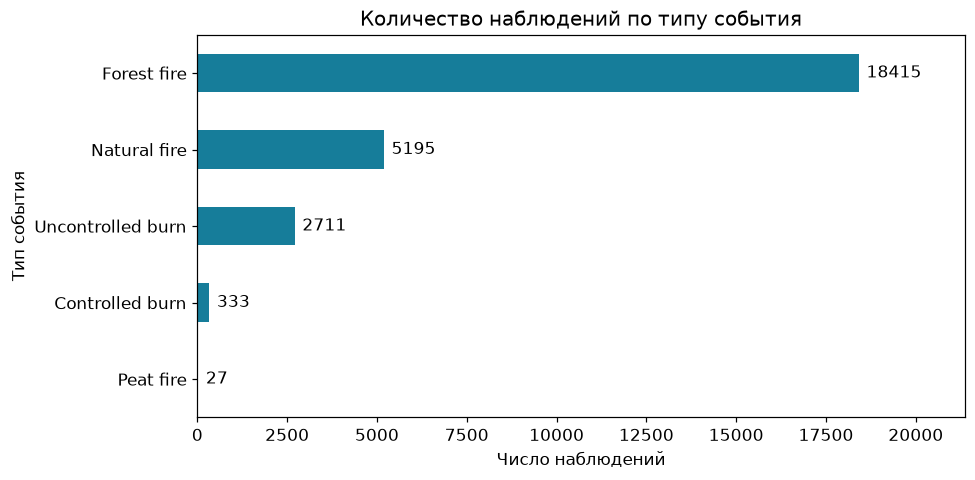

**Вывод.** На диаграмме преобладает категория Forest fire; распределение категорий неравномерно.

In [12]:
counts = df.type_name.value_counts().sort_values()
ax = counts.plot.barh(figsize=(9, 4.5), color="#167d9a")
ax.bar_label(ax.containers[0], padding=5, fmt="%.0f")
ax.set(xlabel="Число наблюдений", ylabel="Тип события", title="Количество наблюдений по типу события")
ax.set_xlim(0, counts.max() * 1.16)
plt.tight_layout()
plt.savefig(FIG / "01_types.png", dpi=150)
plt.show()
display(Markdown("**Вывод.** На диаграмме преобладает категория Forest fire; распределение категорий неравномерно."))

## 9.2. Распределение температуры

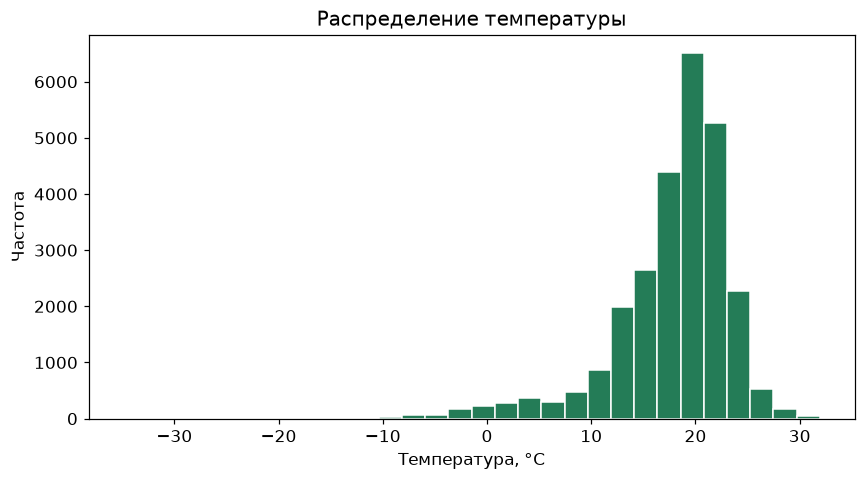

**Вывод.** Основная масса температур положительна; распределение имеет длинный левый хвост. Отрицательные температуры нельзя объявить ошибками без проверки источника.

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df.temperature_c, bins=30, edgecolor="white", color="#247c57")
ax.set(xlabel="Температура, °C", ylabel="Частота", title="Распределение температуры")
plt.tight_layout()
plt.savefig(FIG / "02_temperature.png", dpi=150)
plt.show()
display(Markdown("**Вывод.** Основная масса температур положительна; распределение имеет длинный левый хвост. "
                 "Отрицательные температуры нельзя объявить ошибками без проверки источника."))

## 9.3. Температура и влажность

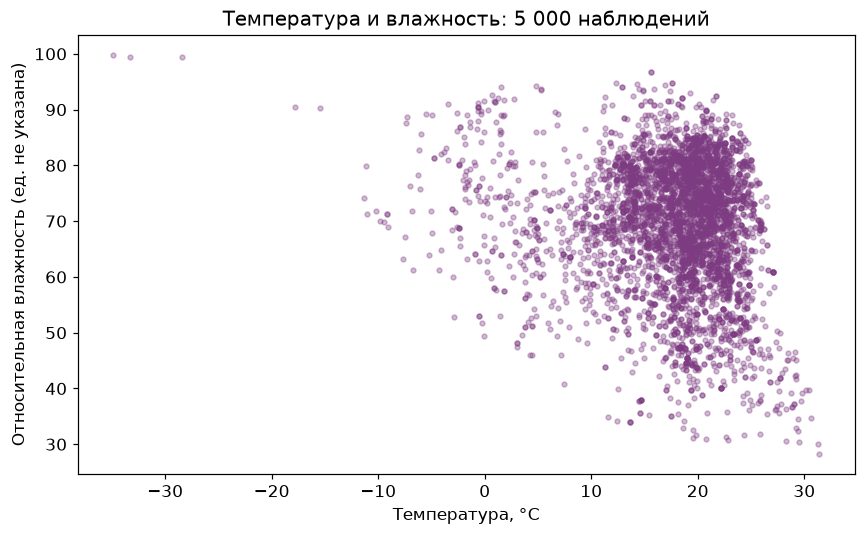

**Вывод.** Облако точек широкое, линейная связь слабо отрицательная (r по всему набору = -0.155). 

In [14]:
sample = df.sample(n=5000, random_state=42)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample.temperature_c, sample.relative_humidity, s=10, alpha=0.35, color="#7d3b81")
ax.set(xlabel="Температура, °C", ylabel="Относительная влажность (ед. не указана)",
       title="Температура и влажность: 5 000 наблюдений")
plt.tight_layout()
plt.savefig(FIG / "03_temperature_humidity.png", dpi=150)
plt.show()
display(Markdown(f"**Вывод.** Облако точек широкое, линейная связь слабо отрицательная "
                 f"(r по всему набору = {corr.loc['temperature_c', 'relative_humidity']:.3f}). "))

## 9.4. Пространственное распределение

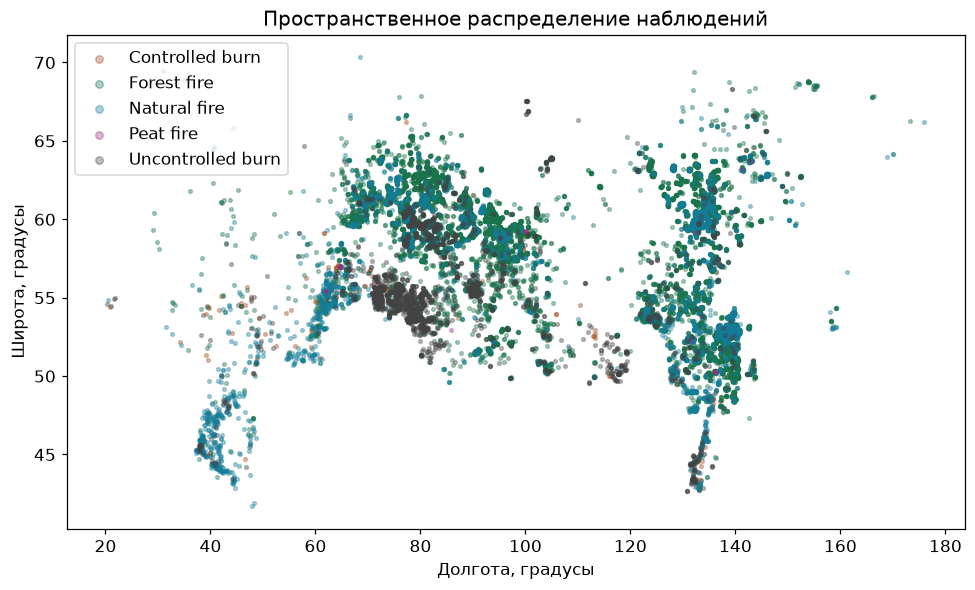

**Вывод.** Наблюдения пространственно неоднородны, видны скопления точек. График показывает расположение событий по долготе и широте.

In [15]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for (name, part), color in zip(df.groupby("type_name", observed=True),
                             ["#a34b19", "#19734b", "#147d99", "#9a3080", "#434343"]):
    ax.scatter(part.lon, part.lat, s=6, alpha=0.35, label=name, color=color)
ax.set(xlabel="Долгота, градусы", ylabel="Широта, градусы", title="Пространственное распределение наблюдений")
ax.legend(loc="upper left", markerscale=2)
plt.tight_layout()
plt.savefig(FIG / "04_coordinates.png", dpi=150)
plt.show()
display(Markdown("**Вывод.** Наблюдения пространственно неоднородны, видны скопления точек. "
                 "График показывает расположение событий по долготе и широте."))

## 10.1-10.2. Экспорт и проверка повторного чтения
Во всех форматах сохраняется одна таблица из 11 столбцов. Время чтения - медиана
пяти последовательных запусков в текущем окружении с прогретым файловым кешем;
это локальный замер, а не универсальное сравнение производительности.

In [16]:
clean_df.to_csv(OUT / "FiresRu_clean.csv", index=False, encoding="utf-8")
clean_df.to_json(OUT / "FiresRu_clean.json", orient="records", lines=True, force_ascii=False, double_precision=15)
clean_df.to_parquet(OUT / "FiresRu_clean.parquet", index=False, engine="pyarrow", compression="snappy")
readers = {
    "csv": lambda: pd.read_csv(OUT / "FiresRu_clean.csv", encoding="utf-8"),
    "json": lambda: pd.read_json(OUT / "FiresRu_clean.json", orient="records", lines=True),
    "parquet": lambda: pd.read_parquet(OUT / "FiresRu_clean.parquet", engine="pyarrow"),
}
back = {fmt: reader() for fmt, reader in readers.items()}
file_stats = []
for fmt, reader in readers.items():
    restored = back[fmt]
    assert restored.shape == clean_df.shape
    if fmt == "parquet":
        pd.testing.assert_frame_equal(clean_df, restored, check_exact=True)
    else:
        pd.testing.assert_frame_equal(clean_df, restored.astype(clean_df.dtypes),
                                      check_exact=False, rtol=1e-10, atol=1e-9)
    durations = []
    for _ in range(5):
        start = perf_counter()
        reader()
        durations.append((perf_counter() - start) * 1000)
    path = OUT / f"FiresRu_clean.{fmt}"
    file_stats.append({"Формат": fmt, "Байт": path.stat().st_size,
                       "MiB": path.stat().st_size / 1024**2, "Чтение, мс": np.median(durations),
                       "Строк": len(restored), "Столбцов": len(restored.columns), "Значения совпали": True})
file_stats = pd.DataFrame(file_stats).set_index("Формат")
display(file_stats)
display(pd.DataFrame({"До записи": clean_df.dtypes.astype(str),
                      **{fmt: data.dtypes.astype(str) for fmt, data in back.items()}}))
selected_columns = ["type_name", "temperature_c"]
partial = pd.read_parquet(OUT / "FiresRu_clean.parquet", columns=selected_columns)
pd.testing.assert_frame_equal(partial, clean_df[selected_columns])
display(Markdown("**Вывод.** Во всех трёх файлах совпадают строки, столбцы и значения "
                 "(для текстовых чисел допуск 1e-9 плюс относительный 1e-10). Parquet сохранил "
                 "значения и dtypes точно, включая `category` и `int8`. CSV/JSON потребовали "
                 "обратного приведения по известной схеме. Выборочное чтение двух колонок Parquet проверено; "
                 "у CSV `usecols` тоже ограничивает результат, но текст всё равно приходится разбирать."))

,Байт,MiB,"Чтение, мс",Строк,Столбцов,Значения совпали
Формат,,,,,,
csv,1827275,1.743,23.298,26681,11,True
json,7183440,6.851,158.043,26681,11,True
parquet,635707,0.606,4.945,26681,11,True


,До записи,csv,json,parquet
type_name,category,object,object,category
type_id,int8,int64,int64,int8
lon,float64,float64,float64,float64
lat,float64,float64,float64,float64
temperature_c,float64,float64,float64,float64
precipitation_mm,float64,float64,float64,float64
relative_humidity,float64,float64,float64,float64
wind_speed_ms,float64,float64,float64,float64
solar_radiation,float64,float64,float64,float64
wind_speed_kmh,float64,float64,float64,float64


**Вывод.** Во всех трёх файлах совпадают строки, столбцы и значения (для текстовых чисел допуск 1e-9 плюс относительный 1e-10). Parquet сохранил значения и dtypes точно, включая `category` и `int8`. CSV/JSON потребовали обратного приведения по известной схеме. Выборочное чтение двух колонок Parquet проверено; у CSV `usecols` тоже ограничивает результат, но текст всё равно приходится разбирать.

## 11. Итоговые выводы и ограничения

In [17]:
summary = {
    "source_rows": len(df), "source_columns": df.shape[1], "clean_rows": len(clean_df),
    "clean_columns": clean_df.shape[1], "missing": int(df.isna().sum().sum()),
    "duplicates": duplicates, "memory_before_bytes": before, "memory_after_bytes": after,
    "memory_reduction_pct": memory_reduction, "filter_rows": len(subset),
    "wind_iqr_candidates": int(mask.sum()), "forest_share_pct": float(type_stats.loc["Forest fire", "share_pct"]),
    "roundtrip_all_formats": True,
}
(OUT / "summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
type_stats.to_csv(OUT / "type_stats.csv", encoding="utf-8")
group_stats.to_csv(OUT / "group_stats.csv", encoding="utf-8")
file_stats.to_csv(OUT / "format_comparison.csv", encoding="utf-8")
display(Markdown(f"""
1. В исходном файле {len(df):,} строк и 9 признаков. Пропуски и полные дубли отсутствуют, все строки сохранены.
2. Пять категорий сильно несбалансированы: доля Forest fire составляет {type_stats.loc['Forest fire', 'share_pct']:.2f}%, Peat fire представлен 27 строками.
3. Код `type_id` не является измеряемой величиной и исключён из числовой статистики и корреляции.
4. Оптимизация одинаковых исходных столбцов снизила память на {memory_reduction:.1f}% без потери значений.
5. Медиана температуры равна {df.temperature_c.median():.2f} °C; у осадков и скорости ветра выражены правые хвосты.
6. Учебному фильтру влажности и ветра соответствуют {len(subset)} строк.
7. IQR помечает {mask.sum():,} скоростей ветра ({mask.mean():.2%}); основания для автоматического удаления отсутствуют.
8. Экспортировано {clean_df.shape[1]} столбцов в CSV, JSON Lines и Parquet, обратное чтение проверено по содержимому.

**Ограничения.** Нет дат, поэтому нельзя исследовать сезонность и динамику. Нет описания схемы сбора,
поэтому нельзя переносить доли на все пожары России. Единицы влажности и радиации не подтверждены.
Пространственная близость может нарушать независимость наблюдений; корреляции не доказывают причинность.
"""))


1. В исходном файле 26,681 строк и 9 признаков. Пропуски и полные дубли отсутствуют, все строки сохранены.
2. Пять категорий сильно несбалансированы: доля Forest fire составляет 69.02%, Peat fire представлен 27 строками.
3. Код `type_id` не является измеряемой величиной и исключён из числовой статистики и корреляции.
4. Оптимизация одинаковых исходных столбцов снизила память на 56.3% без потери значений.
5. Медиана температуры равна 19.08 °C; у осадков и скорости ветра выражены правые хвосты.
6. Учебному фильтру влажности и ветра соответствуют 337 строк.
7. IQR помечает 3,652 скоростей ветра (13.69%); основания для автоматического удаления отсутствуют.
8. Экспортировано 11 столбцов в CSV, JSON Lines и Parquet, обратное чтение проверено по содержимому.

**Ограничения.** Нет дат, поэтому нельзя исследовать сезонность и динамику. Нет описания схемы сбора,
поэтому нельзя переносить доли на все пожары России. Единицы влажности и радиации не подтверждены.
Пространственная близость может нарушать независимость наблюдений; корреляции не доказывают причинность.
